# Lanzarote Weekly Audit + EDA

**Project:** Climate–Mortality

**Goal:**: QA → temperature → calima → interaction → short narrative close.


## 0. Setup
Parameters, paths, and shared helper utilities.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---- island parameters: edit these four values ----
ISLAND_NAME = "lanzarote"
ISLAND_CODE = "lzt"
ISLAND_SLUG = "lanzarote"   # used in data/processed/<slug>/...
REPORT_CODE = "lzt"           # used in reports/<code>/
FIG_SLUG = "lanzarote"      # used in reports/figures/islas/<slug>/eda
MASTER_FILENAME = "master_lzt_2015_2024.parquet"
CALIMA_FILENAME = "calima_proxy_weekly_lzt_2015_2024_v2.parquet"

CWD = Path.cwd().resolve()

# If running from islands/<island>, go up two levels to repo root
if CWD.name == ISLAND_NAME and CWD.parent.name == "islands":
    ROOT = CWD.parent.parent
else:
    ROOT = CWD

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("CWD :", CWD)
print("ROOT:", ROOT)
print("src exists?:", (ROOT / "src").exists())

# --- shared notebook helpers ---
from src.utils.d25_nb_utils import (
    section, glance, checks, missing_table, num_summary, set_island_paths,
    autosave_fig, save_table,
)

# --- reports output paths ---
REPORTS_DIR = ROOT / "reports" / "islands"
FIG_DIR = REPORTS_DIR / "figures" / ISLAND_NAME
TAB_DIR = REPORTS_DIR / "tables" / ISLAND_NAME

FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print("FIG_DIR:", FIG_DIR)
print("TAB_DIR:", TAB_DIR)

# --- data input ---
FP = ROOT / "data/processed" / ISLAND_NAME / "master" / f"master_{ISLAND_CODE}_2015_2024.parquet"
print("FP:", FP)

assert FP.exists(), f"Missing file: {FP}"

CWD : C:\dev\projects\climate_mortality\islands\lanzarote
ROOT: C:\dev\projects\climate_mortality
src exists?: True
FIG_DIR: C:\dev\projects\climate_mortality\reports\islands\figures\lanzarote
TAB_DIR: C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote
FP: C:\dev\projects\climate_mortality\data\processed\lanzarote\master\master_lzt_2015_2024.parquet


## 1. Load data
Load the island master dataset and subset to the chosen island code if needed.


In [2]:
section(f"EDA core weekly {ISLAND_NAME}")

df = pd.read_parquet(FP)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")

if "island_code" in df.columns:
    df = df.loc[df["island_code"].eq(ISLAND_CODE)].copy()

glance(df, label=f"eda_core_weekly_{ISLAND_CODE}", n=5)
display(checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start"))
display(num_summary(df))



EDA core weekly lanzarote

--- eda_core_weekly_lzt ---
shape: (471, 37)

dtypes:
 week_start                     datetime64[ns]
year                                    int32
island                                 object
island_code                            object
deaths_week                           float64
deaths_missing_week                     int64
temp_c_mean                           float64
tmax_c_mean                           float64
tmin_c_mean                           float64
humidity_mean                         float64
pressure_hpa_mean                     float64
wind_ms_mean                          float64
low_vis_confirmed_days_week             int64
low_vis_confirmed_any_week              int64
low_vis_possible_days_week              int64
low_vis_possible_any_week               int64
low_vis_any_days_week                   int64
low_vis_any_week                        int64
confirmed_airports_max_week             int64
possible_airports_max_week              int

,week_start,year,island,island_code,deaths_week,deaths_missing_week,temp_c_mean,tmax_c_mean,tmin_c_mean,humidity_mean,...,O3,days_with_pm10,days_missing_pm10,cap_heat_level_max_week,cap_dust_level_max_week,cap_heat_yellow_plus_week,cap_dust_yellow_plus_week,cap_coverage_week,calima_dai_flag,calima_level_week
0,2015-12-28,2015,lanzarote,lzt,12.0,0,18.366667,22.833333,13.900000,76.000000,...,63.000000,3,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,2016-01-04,2016,lanzarote,lzt,15.0,0,18.585714,22.671429,14.500000,70.428571,...,72.714286,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
2,2016-01-11,2016,lanzarote,lzt,15.0,0,19.028571,23.928571,14.142857,69.428571,...,70.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,2016-01-18,2016,lanzarote,lzt,14.0,0,19.300000,23.528571,15.014286,66.857143,...,70.000000,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0
4,2016-01-25,2016,lanzarote,lzt,11.0,0,18.785714,22.928571,14.642857,63.571429,...,82.857143,7,0,NaN,NaN,NaN,NaN,NaN,0.0,0.0


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=997
4,deaths_nonnegative,True,neg=0


,count,mean,std,min,25%,50%,75%,max
year,471.0,2019.993631,2.594996,2015.000000,2018.000000,2020.000000,2022.000000,2024.000000
deaths_week,471.0,15.454352,4.418715,4.000000,12.000000,15.000000,18.000000,31.000000
deaths_missing_week,471.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
temp_c_mean,471.0,21.823972,3.040844,14.500000,19.157143,21.757143,24.421429,29.214286
tmax_c_mean,471.0,26.045464,3.314672,18.228571,23.300000,26.057143,28.607143,34.871429
tmin_c_mean,471.0,17.600861,2.850791,10.785714,15.078571,17.571429,20.250000,24.000000
humidity_mean,471.0,63.943282,5.459263,38.142857,60.857143,64.000000,67.142857,81.000000
pressure_hpa_mean,471.0,1015.979117,3.319275,1007.407143,1013.646429,1015.285714,1017.735714,1025.885714
wind_ms_mean,471.0,6.282747,1.944211,1.871429,4.721429,6.100000,7.728571,12.185714
low_vis_confirmed_days_week,471.0,0.853503,1.185813,0.000000,0.000000,0.000000,1.000000,6.000000


In [3]:
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df["month"] = df["week_start"].dt.month
df = df.sort_values("week_start").reset_index(drop=True)

if "tmax_anom_mean" not in df.columns and "tmax_c_mean" in df.columns:
    monthly_ref = df.groupby("month")["tmax_c_mean"].transform("mean")
    df["tmax_anom_mean"] = df["tmax_c_mean"] - monthly_ref
    print("Created tmax_anom_mean from tmax_c_mean using month-of-year mean.")
else:
    print("tmax_anom_mean already present.")

if "excess_deaths" not in df.columns and "deaths_week" in df.columns:
    deaths_ref = df.groupby("month")["deaths_week"].transform("mean")
    df["excess_deaths"] = df["deaths_week"] - deaths_ref
    print("Created excess_deaths from deaths_week using month-of-year mean.")
else:
    print("excess_deaths already present or deaths_week missing.")

calima_fp = ROOT / "data" / "processed" / ISLAND_SLUG / "calima" / CALIMA_FILENAME
print("Calima proxy FP:", calima_fp)

if calima_fp.exists():
    calima = pd.read_parquet(calima_fp).copy()
    calima["week_start"] = pd.to_datetime(calima["week_start"], errors="coerce")

    keep = ["week_start", "calima_proxy_score_v2", "calima_proxy_level_v2"]
    extra_keep = [c for c in ["cap_dust_yellow_plus_week", "cap_dust_level_max_week", "calima_dai_flag"] if c in calima.columns]
    calima_keep = [c for c in keep + extra_keep if c in calima.columns]

    overlap = [c for c in calima_keep if c != "week_start" and c in df.columns]
    if overlap:
        df = df.drop(columns=overlap)

    df = df.merge(calima[calima_keep], on="week_start", how="left")
    print("Merged calima proxy columns:", [c for c in calima_keep if c != "week_start"])
else:
    print("Calima proxy weekly dataset not found. Section 6.1 will be skipped.")


Created tmax_anom_mean from tmax_c_mean using month-of-year mean.
Created excess_deaths from deaths_week using month-of-year mean.
Calima proxy FP: C:\dev\projects\climate_mortality\data\processed\lanzarote\calima\calima_proxy_weekly_lzt_2015_2024_v2.parquet
Merged calima proxy columns: ['calima_proxy_score_v2', 'calima_proxy_level_v2', 'cap_dust_yellow_plus_week', 'cap_dust_level_max_week', 'calima_dai_flag']


## 2. QA / Audit
Minimal checks to confirm weekly uniqueness, required columns, and coverage.


In [4]:
qa = checks(df, required=["week_start", "deaths_week"], key=["week_start"], dt="week_start")
display(qa)

miss = missing_table(df)
display(miss.head(25))

save_table(qa, TAB_DIR, f"qa_checks_{ISLAND_CODE}.csv", index=False)
save_table(miss.head(50), TAB_DIR, f"missing_top50_{ISLAND_CODE}.csv")


,name,ok,detail
0,required_cols_present,True,ok
1,datetime_parse_week_start,True,bad=0
2,duplicates_on_key,True,dups=0
3,total_missing_cells,True,missing_cells=997
4,deaths_nonnegative,True,neg=0


,missing,missing_pct
calima_level_week,146,0.3100
calima_dai_flag,146,0.3100
cap_heat_yellow_plus_week,129,0.2739
cap_dust_yellow_plus_week,129,0.2739
cap_heat_level_max_week,129,0.2739
cap_dust_level_max_week,129,0.2739
cap_coverage_week,129,0.2739
PM2.5,43,0.0913
NO2,17,0.0361
week_start,0,0.0000


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\qa_checks_lzt.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\missing_top50_lzt.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/lanzarote/missing_top50_lzt.csv')

### Data coverage notes
- **CAP alerts are only usable from 2018 onwards** (pre-2018 coverage is not consistently available).
- **DAI flag data are not available after March 2022** (post-Mar-2022 coverage is missing).


## 3. Core descriptive statistics
Quick descriptive tables for the key variables used in the analysis.


In [5]:
core_cols = [
    "deaths_week",
    "temp_c_mean", "tmax_c_mean", "tmin_c_mean",
    "humidity_mean", "pressure_hpa_mean", "wind_ms_mean",
    "PM10", "PM2.5", "SO2", "NO2", "O3",
    "cap_heat_level_max_week", "cap_dust_level_max_week",
    "cap_heat_yellow_plus_week", "cap_dust_yellow_plus_week",
    "cap_coverage_week", "calima_dai_flag",
    "low_vis_any_week", "vis_min_m_week", "rh_min_pct_week"
]
desc = num_summary(df, cols=core_cols)
display(desc)
save_table(desc.reset_index().rename(columns={"index": "variable"}), TAB_DIR, f"desc_core_{ISLAND_CODE}.csv", index=False)


,count,mean,std,min,25%,50%,75%,max
deaths_week,471.0,15.454352,4.418715,4.000000,12.000000,15.000000,18.000000,31.000000
temp_c_mean,471.0,21.823972,3.040844,14.500000,19.157143,21.757143,24.421429,29.214286
tmax_c_mean,471.0,26.045464,3.314672,18.228571,23.300000,26.057143,28.607143,34.871429
tmin_c_mean,471.0,17.600861,2.850791,10.785714,15.078571,17.571429,20.250000,24.000000
humidity_mean,471.0,63.943282,5.459263,38.142857,60.857143,64.000000,67.142857,81.000000
pressure_hpa_mean,471.0,1015.979117,3.319275,1007.407143,1013.646429,1015.285714,1017.735714,1025.885714
wind_ms_mean,471.0,6.282747,1.944211,1.871429,4.721429,6.100000,7.728571,12.185714
PM10,471.0,54.342837,61.373773,15.000000,28.214286,36.428571,54.142857,530.142857
PM2.5,428.0,14.290988,12.779415,1.000000,7.857143,10.857143,15.571429,105.285714
SO2,471.0,6.038682,4.560692,0.428571,3.000000,5.000000,7.773810,37.428571


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\desc_core_lzt.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/lanzarote/desc_core_lzt.csv')

## 4. Time series overview
Weekly deaths and temperature series (context + seasonality).


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_weekly_deaths_timeseries.png


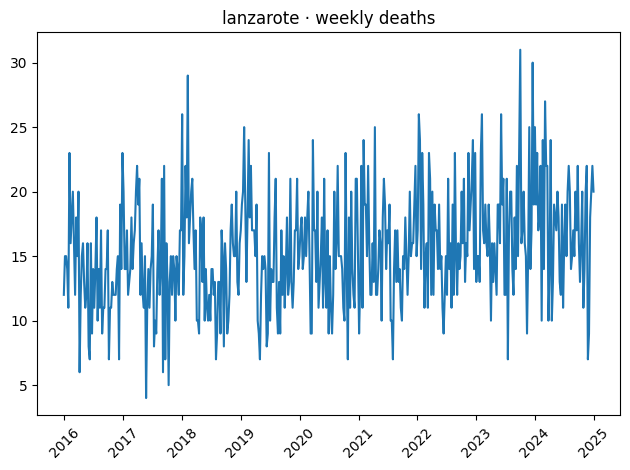

Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_weekly_tmax_timeseries.png


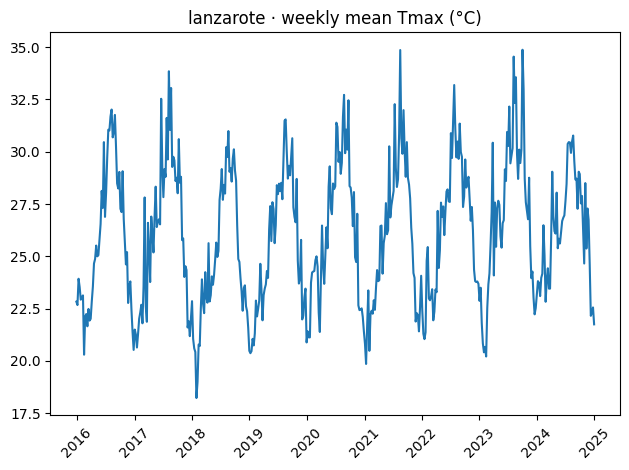

In [6]:
plt.figure()
plt.plot(df["week_start"], df["deaths_week"])
plt.title(f"{ISLAND_NAME} · weekly deaths")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_deaths_timeseries.png")
plt.show()

plt.figure()
plt.plot(df["week_start"], df["tmax_c_mean"])
plt.title(f"{ISLAND_NAME} · weekly mean Tmax (°C)")
plt.xticks(rotation=45)
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_weekly_tmax_timeseries.png")
plt.show()


## 5. Temperature and mortality
### 5.1 Absolute temperature vs deaths
Absolute temperature can be heavily confounded by seasonality.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_deaths_vs_absolute_tmax_scatter.png


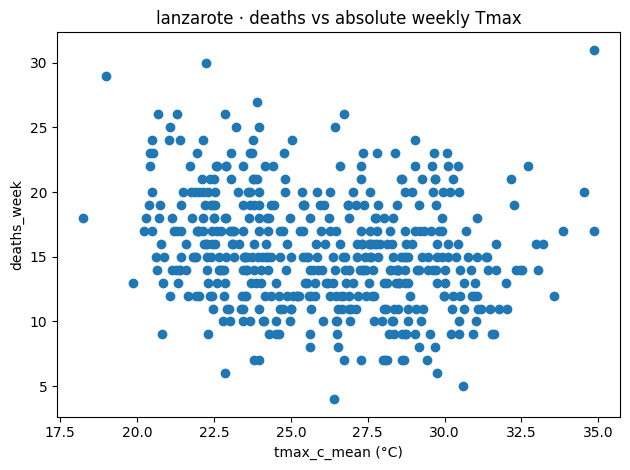

corr(deaths, tmax_c_mean): -0.2121


In [7]:
plt.figure()
plt.scatter(df["tmax_c_mean"], df["deaths_week"])
plt.xlabel("tmax_c_mean (°C)")
plt.ylabel("deaths_week")
plt.title(f"{ISLAND_NAME} · deaths vs absolute weekly Tmax")
plt.tight_layout()
autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_absolute_tmax_scatter.png")
plt.show()

corr_abs = df[["deaths_week", "tmax_c_mean"]].corr().iloc[0, 1]
print("corr(deaths, tmax_c_mean):", round(float(corr_abs), 4))


##### 5.2 Temperature anomaly vs deaths
Use anomalies (relative temperature) to reduce seasonal confounding.


Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_deaths_vs_temperature_anomaly_scatter.png


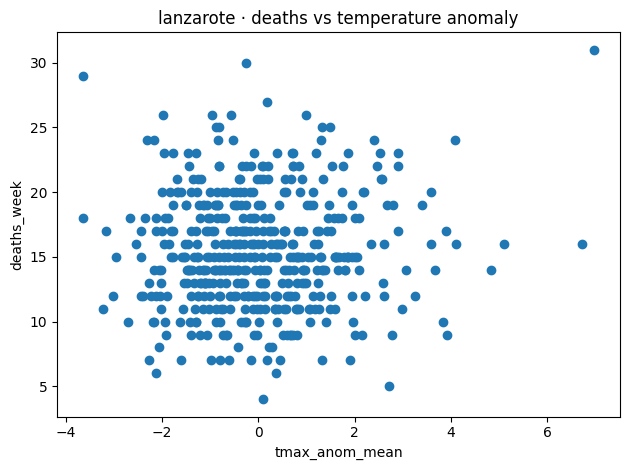

corr(deaths, tmax_anom_mean): 0.0571


In [8]:
anom_col = None
for c in ["tmax_anom_mean_week", "tmax_anom_mean", "tmax_anom_c_mean", "tmax_anom"]:
    if c in df.columns:
        anom_col = c
        break

if anom_col is None:
    print("No anomaly column found in this master. (Skip or create anomalies upstream.)")
else:
    plt.figure()
    plt.scatter(df[anom_col], df["deaths_week"])
    plt.xlabel(anom_col)
    plt.ylabel("deaths_week")
    plt.title(f"{ISLAND_NAME} · deaths vs temperature anomaly")
    plt.tight_layout()
    autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_deaths_vs_temperature_anomaly_scatter.png")
    plt.show()
    corr_anom = df[["deaths_week", anom_col]].corr().iloc[0, 1]
    print(f"corr(deaths, {anom_col}):", round(float(corr_anom), 4))


### 5.3 Extreme heat (p90 / p95)
Compare weeks above an extreme threshold vs the rest.


In [9]:
q90_tmax = df["tmax_c_mean"].quantile(0.90)
q95_tmax = df["tmax_c_mean"].quantile(0.95)

df["heat_p90"] = (df["tmax_c_mean"] >= q90_tmax).astype(int)
df["heat_p95"] = (df["tmax_c_mean"] >= q95_tmax).astype(int)

print(f"Official heat thresholds from tmax_c_mean -> p90={q90_tmax:.2f}, p95={q95_tmax:.2f}")
print(df["heat_p95"].value_counts(dropna=False))

tab_p95 = df.groupby("heat_p95")["deaths_week"].agg(["count", "mean", "median"])
display(tab_p95)

if 0 in tab_p95.index and 1 in tab_p95.index:
    delta_p95 = float(tab_p95.loc[1, "mean"] - tab_p95.loc[0, "mean"])
    print("Δ deaths (heat_p95 vs baseline):", round(delta_p95, 2))

save_table(tab_p95.reset_index(), TAB_DIR, f"heat_p95_deaths_{ISLAND_CODE}.csv", index=False)


Official heat thresholds from tmax_c_mean -> p90=30.43, p95=31.36
heat_p95
0    447
1     24
Name: count, dtype: int64


,count,mean,median
heat_p95,,,
0,447,15.456376,15.0
1,24,15.416667,14.0


Δ deaths (heat_p95 vs baseline): -0.04
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\heat_p95_deaths_lzt.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/lanzarote/heat_p95_deaths_lzt.csv')

## 6. Calima and mortality
Analyze calima intensity proxies vs weekly deaths.

### 6.1 Calima proxy audit
Validate the merged calima proxy coverage and weekly level distribution before using it in downstream comparisons.


,missing,missing_pct
calima_proxy_score_v2,0,0.0
calima_proxy_level_v2,0,0.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_audit_missing_lzt.csv


,calima_proxy_level_v2,weeks
0,no_calima,199
1,possible,181
2,probable,56
3,intense,35


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_level_counts_lzt.csv
Saved figure -> C:\dev\projects\climate_mortality\reports\islands\figures\lanzarote\lzt_eda01_calima_proxy_level_counts.png


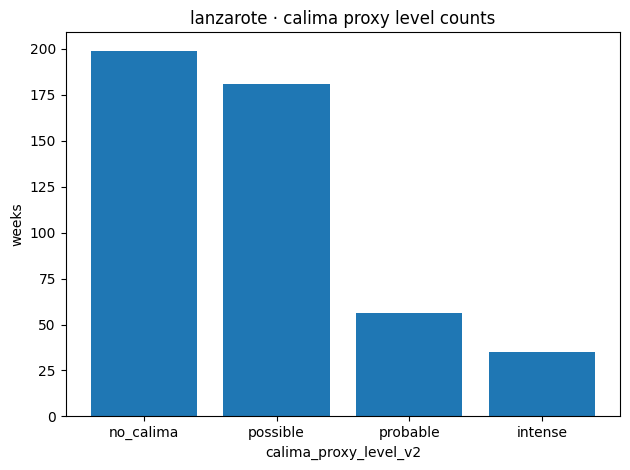

CAP yellow alignment with proxy (probable+intense among CAP yellow): 0.7826


In [10]:
proxy_cols = ["calima_proxy_score_v2", "calima_proxy_level_v2"]
have_proxy = all(c in df.columns for c in proxy_cols)

if have_proxy:
    proxy_na = df[proxy_cols].isna().sum().rename("missing").to_frame()
    proxy_na["missing_pct"] = (proxy_na["missing"] / len(df)).round(4)
    display(proxy_na)
    save_table(proxy_na.reset_index().rename(columns={"index": "column"}), TAB_DIR, f"calima_proxy_audit_missing_{ISLAND_CODE}.csv", index=False)

    proxy_counts = (
        df["calima_proxy_level_v2"]
        .value_counts(dropna=False)
        .rename_axis("calima_proxy_level_v2")
        .reset_index(name="weeks")
    )
    display(proxy_counts)
    save_table(proxy_counts, TAB_DIR, f"calima_proxy_level_counts_{ISLAND_CODE}.csv", index=False)

    plot_counts = df["calima_proxy_level_v2"].dropna().value_counts()
    if not plot_counts.empty:
        desired_order = ["no_calima", "possible", "probable", "intense"]
        plot_counts = plot_counts.reindex([x for x in desired_order if x in plot_counts.index])

        plt.figure()
        plt.bar(plot_counts.index.astype(str), plot_counts.values)
        plt.title(f"{ISLAND_NAME} · calima proxy level counts")
        plt.xlabel("calima_proxy_level_v2")
        plt.ylabel("weeks")
        plt.tight_layout()
        autosave_fig(plt.gcf(), FIG_DIR, f"{ISLAND_CODE}_eda01_calima_proxy_level_counts.png")
        plt.show()

    if {"cap_dust_yellow_plus_week", "calima_proxy_level_v2"}.issubset(df.columns):
        tmp = df.copy()
        tmp["proxy_ge_probable"] = tmp["calima_proxy_level_v2"].isin(["probable", "intense"])
        cap_yellow = tmp["cap_dust_yellow_plus_week"] == 1
        alignment = tmp.loc[cap_yellow, "proxy_ge_probable"].mean()
        print("CAP yellow alignment with proxy (probable+intense among CAP yellow):", round(float(alignment), 4))
else:
    print("No calima proxy level column found in this master.")


### 6.2 Calima levels and deaths
Compare weekly deaths across calima proxy levels (or DAI fallback if proxy columns are unavailable).


In [11]:
if "calima_proxy_level_v2" in df.columns:
    cal = df.groupby("calima_proxy_level_v2")["deaths_week"].agg(["count", "mean", "median"])
    level_order = ["no_calima", "possible", "probable", "intense"]
    cal = cal.reindex([x for x in level_order if x in cal.index])
    display(cal)
    save_table(cal.reset_index(), TAB_DIR, f"calima_proxy_level_v2_deaths_{ISLAND_CODE}.csv", index=False)
else:
    print("No calima_proxy_level_v2. Using calima_dai_flag if available...")
    if "calima_dai_flag" in df.columns:
        cal = df.groupby("calima_dai_flag")["deaths_week"].agg(["count", "mean", "median"]).sort_index()
        display(cal)
        save_table(cal.reset_index(), TAB_DIR, f"calima_dai_flag_deaths_{ISLAND_CODE}.csv", index=False)


,count,mean,median
calima_proxy_level_v2,,,
no_calima,199,15.306533,15.0
possible,181,15.055249,15.0
probable,56,15.035714,15.0
intense,35,19.028571,19.0


Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\calima_proxy_level_v2_deaths_lzt.csv


## 7. Interaction: extreme heat × calima
A simple 2×2 cross-tab.


In [12]:
tmp = df.copy()

if "calima_proxy_level_v2" in tmp.columns:
    tmp["calima_intense"] = (tmp["calima_proxy_level_v2"] == "intense").astype(int)
else:
    tmp["calima_intense"] = 0

# 2x2 count table to verify whether joint exposure exists
ct = pd.crosstab(tmp["heat_p95"], tmp["calima_intense"], dropna=False)
display(ct)

joint_n = ((tmp["heat_p95"] == 1) & (tmp["calima_intense"] == 1)).sum()
print(f"Weeks with heat_p95=1 and calima_intense=1: {joint_n}")

# Descriptive mortality summary by joint exposure group
inter = (
    tmp.groupby(["heat_p95", "calima_intense"])["deaths_week"]
       .agg(["count", "mean", "median"])
       .reindex(pd.MultiIndex.from_product([[0, 1], [0, 1]],
                                           names=["heat_p95", "calima_intense"]))
)

inter["count"] = inter["count"].fillna(0).astype(int)

display(inter)

save_table(ct.reset_index(), TAB_DIR, f"interaction_counts_heat_p95_x_calima_intense_{ISLAND_CODE}.csv", index=False)
save_table(inter.reset_index(), TAB_DIR, f"interaction_heat_p95_x_calima_intense_{ISLAND_CODE}.csv", index=False)


calima_intense,0,1
heat_p95,,
0,414,33
1,22,2


Weeks with heat_p95=1 and calima_intense=1: 2


count       mean  median
heat_p95 calima_intense                          
0        0                 414  15.200483    15.0
         1                  33  18.666667    19.0
1        0                  22  14.545455    14.0
         1                   2  25.000000    25.0

Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\interaction_counts_heat_p95_x_calima_intense_lzt.csv
Saved table -> C:\dev\projects\climate_mortality\reports\islands\tables\lanzarote\interaction_heat_p95_x_calima_intense_lzt.csv


WindowsPath('C:/dev/projects/climate_mortality/reports/islands/tables/lanzarote/interaction_heat_p95_x_calima_intense_lzt.csv')

### Key numbers to report
- Δ deaths (heat p95 vs baseline): **-0.04**
- Δ deaths (calima intense vs no_calima): **+3.72 deaths/week**
- Proxy coverage / missingness: **0.00%**
- CAP yellow alignment with proxy: **0.7826**
- corr(deaths, tmax_c_mean): **-0.2121**
- corr(deaths, Tmax anomaly): **0.0571**


### Summary.
Overall, the Lanzarote audit/EDA passes the main quality checks. week_start parses correctly, no duplicate weekly keys were found, and no negative death counts were detected. Weekly mortality coverage is complete in this dataset, which is a strength relative to some other islands. However, environmental coverage is uneven: CAP-based heat and dust variables are only available for part of the series (342 of 471 weeks, about 72.6%), DAI/calima-related fields are missing for roughly 31% of weeks, and PM2.5 and NO2 also show some missingness.

From a descriptive perspective, the weekly heat signal appears weak. Extreme heat weeks defined using the weekly Tmax p95 threshold (31.36°C) show virtually no difference in mean mortality compared with baseline weeks (15.42 vs 15.46 deaths/week; Δ = -0.04). In addition, the correlation between deaths and Tmax anomaly is close to zero, which suggests that short-term temperature deviations do not show a clear mortality pattern in this weekly exploratory view.

By contrast, the calima signal is more noticeable. Mean weekly deaths are clearly higher in intense calima weeks than in no_calima weeks (19.03 vs 15.31 deaths/week). This makes calima a more relevant descriptive signal than heat in the current Lanzarote EDA. Still, this should be interpreted cautiously: the result is observational and descriptive, not causal, and may still reflect seasonality or other unmeasured factors.

The joint exposure analysis is especially limited. Only 2 weeks in the full series are classified as both heat_p95=1 and calima_intense=1, so no meaningful conclusion can be drawn about interaction or compound effects between extreme heat and intense calima in Lanzarote at weekly resolution.

In summary, Lanzarote appears to show a weak weekly heat signal but a stronger descriptive calima signal, with the main limitation being incomplete environmental coverage and the very low number of joint extreme heat + intense calima weeks. Any interpretation should therefore remain exploratory and comparative rather than inferential.